In [1]:
# ============================================
# Cell 1: Setup
# ============================================

import os
import numpy as np
import pandas as pd

from google.colab import drive

drive.mount("/content/drive")

BASE_DIR = "/content/drive/MyDrive/気合のCOVID19"

print("BASE_DIR:", BASE_DIR)
print("Exists:", os.path.exists(BASE_DIR))

Mounted at /content/drive
BASE_DIR: /content/drive/MyDrive/気合のCOVID19
Exists: True


In [2]:
# ============================================
# Cell 2: Input paths
# ============================================

CXR_VAL_PATH = os.path.join(
    BASE_DIR,
    "01_TaskA_CXR",
    "05_Evaluation",
    "TaskA_CXR_Validation患者別予測結果.csv"
)

LR_VAL_PATH = os.path.join(
    BASE_DIR,
    "02_TaskB_臨床データ",
    "04_Modeling",
    "TaskB_LR_8条件_Validation患者別予測確率.csv"
)

print("CXR Validation:", os.path.exists(CXR_VAL_PATH))
print("LR Validation :", os.path.exists(LR_VAL_PATH))

CXR Validation: True
LR Validation : True


In [3]:
# ============================================
# Cell 3: Load Validation predictions
# ============================================

cxr_val = pd.read_csv(CXR_VAL_PATH)
lr_val = pd.read_csv(LR_VAL_PATH)

print("=== CXR Validation ===")
print("Shape:", cxr_val.shape)
print("Columns:", cxr_val.columns.tolist())

print("\n=== LR Validation ===")
print("Shape:", lr_val.shape)
print("Columns:", lr_val.columns.tolist())

display(cxr_val.head())
display(lr_val.head())

=== CXR Validation ===
Shape: (128, 4)
Columns: ['Subject ID', 'true_label', 'prob_death', 'model_name']

=== LR Validation ===
Shape: (128, 10)
Columns: ['Subject ID', 'true_label', 'C=0.01_class_weight=None', 'C=0.01_class_weight=balanced', 'C=0.1_class_weight=None', 'C=0.1_class_weight=balanced', 'C=1_class_weight=None', 'C=1_class_weight=balanced', 'C=10_class_weight=None', 'C=10_class_weight=balanced']


,Subject ID,true_label,prob_death,model_name
0,A469587,0,0.453027,CXR_ResNet18
1,A851902,1,0.146410,CXR_ResNet18
2,A018604,0,0.042571,CXR_ResNet18
3,A209932,0,0.027871,CXR_ResNet18
4,A436797,0,0.079438,CXR_ResNet18


,Subject ID,true_label,C=0.01_class_weight=None,C=0.01_class_weight=balanced,C=0.1_class_weight=None,C=0.1_class_weight=balanced,C=1_class_weight=None,C=1_class_weight=balanced,C=10_class_weight=None,C=10_class_weight=balanced
0,A601967,0,0.182375,0.369260,0.087346,0.256331,0.049018,0.183794,0.036690,0.166305
1,A279745,1,0.610836,0.891175,0.723624,0.953378,0.835513,0.974219,0.870383,0.978299
2,A918856,0,0.082804,0.173552,0.023324,0.106626,0.020777,0.109441,0.020887,0.107246
3,A690597,0,0.216780,0.319133,0.067523,0.144116,0.014742,0.054938,0.007504,0.040812
4,A441526,0,0.105706,0.279560,0.040748,0.211855,0.047456,0.250636,0.053376,0.262965


In [4]:
# ============================================
# Cell 4: Validation predictions を Subject ID で結合
# ============================================

# Task A側
cxr_use = cxr_val[
    ["Subject ID", "true_label", "prob_death"]
].copy()

cxr_use = cxr_use.rename(
    columns={"prob_death": "cxr_prob"}
)

# Task B側
LR_FINAL_COL = "C=1_class_weight=None"

lr_use = lr_val[
    ["Subject ID", "true_label", LR_FINAL_COL]
].copy()

lr_use = lr_use.rename(
    columns={LR_FINAL_COL: "clinical_prob"}
)

# 1対1で結合
fusion_val = cxr_use.merge(
    lr_use,
    on="Subject ID",
    how="inner",
    suffixes=("_cxr", "_clinical"),
    validate="one_to_one"
)

print("Merged shape:", fusion_val.shape)
display(fusion_val.head())

Merged shape: (128, 5)


,Subject ID,true_label_cxr,cxr_prob,true_label_clinical,clinical_prob
0,A469587,0,0.453027,0,0.019780
1,A851902,1,0.146410,1,0.234897
2,A018604,0,0.042571,0,0.037711
3,A209932,0,0.027871,0,0.027850
4,A436797,0,0.079438,0,0.048880


In [5]:
# ============================================
# Cell 5: 結合監査
# ============================================

print("=== Validation merge audit ===")

print("Rows               :", len(fusion_val))
print("Unique IDs         :", fusion_val["Subject ID"].nunique())

label_match = (
    fusion_val["true_label_cxr"]
    == fusion_val["true_label_clinical"]
).all()

print("Labels identical   :", label_match)

cxr_ids = set(cxr_use["Subject ID"])
lr_ids = set(lr_use["Subject ID"])

print("Only in CXR        :", len(cxr_ids - lr_ids))
print("Only in Clinical   :", len(lr_ids - cxr_ids))

print("Missing CXR prob   :", fusion_val["cxr_prob"].isna().sum())
print("Missing Clinical p :", fusion_val["clinical_prob"].isna().sum())

print(
    "CXR probability range     :",
    fusion_val["cxr_prob"].min(),
    "-",
    fusion_val["cxr_prob"].max()
)

print(
    "Clinical probability range:",
    fusion_val["clinical_prob"].min(),
    "-",
    fusion_val["clinical_prob"].max()
)

assert len(fusion_val) == 128
assert fusion_val["Subject ID"].nunique() == 128
assert label_match
assert len(cxr_ids - lr_ids) == 0
assert len(lr_ids - cxr_ids) == 0
assert fusion_val["cxr_prob"].isna().sum() == 0
assert fusion_val["clinical_prob"].isna().sum() == 0
assert fusion_val["cxr_prob"].between(0, 1).all()
assert fusion_val["clinical_prob"].between(0, 1).all()

print("\nAudit OK")

=== Validation merge audit ===
Rows               : 128
Unique IDs         : 128
Labels identical   : True
Only in CXR        : 0
Only in Clinical   : 0
Missing CXR prob   : 0
Missing Clinical p : 0
CXR probability range     : 0.017134555 - 0.9891021
Clinical probability range: 0.0012785004139062 - 0.9115847687764664

Audit OK


In [6]:
# ============================================
# Cell 6: Late Fusion用Validation tableを完成
# ============================================

fusion_val["true_label"] = (
    fusion_val["true_label_cxr"].astype(int)
)

fusion_val = fusion_val[
    [
        "Subject ID",
        "true_label",
        "cxr_prob",
        "clinical_prob"
    ]
].copy()

print("Final shape :", fusion_val.shape)
print("Deaths      :", int(fusion_val["true_label"].sum()))

display(fusion_val.head())

Final shape : (128, 4)
Deaths      : 17


,Subject ID,true_label,cxr_prob,clinical_prob
0,A469587,0,0.453027,0.019780
1,A851902,1,0.146410,0.234897
2,A018604,0,0.042571,0.037711
3,A209932,0,0.027871,0.027850
4,A436797,0,0.079438,0.048880


In [7]:
# ============================================
# Cell 7: Late Fusion用Validation tableを保存
# ============================================

TASKC_DIR = os.path.join(
    BASE_DIR,
    "03_TaskC_マルチモーダル"
)

os.makedirs(TASKC_DIR, exist_ok=True)

SAVE_PATH = os.path.join(
    TASKC_DIR,
    "TaskC_LateFusion_Validation入力.csv"
)

fusion_val.to_csv(
    SAVE_PATH,
    index=False,
    encoding="utf-8-sig"
)

print("=== 保存完了 ===")
print("Path       :", SAVE_PATH)
print("Rows       :", len(fusion_val))
print("Unique IDs :", fusion_val["Subject ID"].nunique())
print("Deaths     :", int(fusion_val["true_label"].sum()))

=== 保存完了 ===
Path       : /content/drive/MyDrive/気合のCOVID19/03_TaskC_マルチモーダル/TaskC_LateFusion_Validation入力.csv
Rows       : 128
Unique IDs : 128
Deaths     : 17


In [8]:
# ============================================
# Cell 8: Late Fusion weight search on Validation
# ============================================

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    brier_score_loss
)

results = []

y_true = fusion_val["true_label"].values
cxr_prob = fusion_val["cxr_prob"].values
clinical_prob = fusion_val["clinical_prob"].values

for w_clinical in np.arange(0.00, 1.001, 0.01):

    w_cxr = 1.0 - w_clinical

    fusion_prob = (
        w_clinical * clinical_prob
        + w_cxr * cxr_prob
    )

    roc_auc = roc_auc_score(y_true, fusion_prob)
    pr_auc = average_precision_score(y_true, fusion_prob)
    brier = brier_score_loss(y_true, fusion_prob)

    results.append({
        "w_clinical": w_clinical,
        "w_cxr": w_cxr,
        "roc_auc": roc_auc,
        "pr_auc": pr_auc,
        "brier_score": brier
    })

weight_results = pd.DataFrame(results)

display(
    weight_results
    .sort_values(
        ["roc_auc", "pr_auc"],
        ascending=[False, False]
    )
    .head(15)
)

,w_clinical,w_cxr,roc_auc,pr_auc,brier_score
72,0.72,0.28,0.91256,0.654359,0.075352
73,0.73,0.27,0.91150,0.653476,0.075261
74,0.74,0.26,0.91150,0.651661,0.075186
67,0.67,0.33,0.91097,0.659508,0.076064
68,0.68,0.32,0.91097,0.655984,0.075888
75,0.75,0.25,0.91097,0.648730,0.075129
66,0.66,0.34,0.91044,0.659862,0.076258
69,0.69,0.31,0.91044,0.653183,0.075729
71,0.71,0.29,0.91044,0.649088,0.075461
76,0.76,0.24,0.91044,0.647473,0.075088


In [9]:
# ============================================
# Cell 9: Select best weight
# ============================================

max_auc = weight_results["roc_auc"].max()

best_candidates = weight_results[
    np.isclose(
        weight_results["roc_auc"],
        max_auc
    )
].copy()

print("Maximum Validation ROC-AUC:", max_auc)
print("Number of tied weights:", len(best_candidates))

display(best_candidates)

Maximum Validation ROC-AUC: 0.9125596184419713
Number of tied weights: 1


,w_clinical,w_cxr,roc_auc,pr_auc,brier_score
72,0.72,0.28,0.91256,0.654359,0.075352


In [10]:
# ============================================
# Cell 10: Final Validation-based weight selection
# ============================================

best_row = (
    weight_results
    .sort_values(
        by=[
            "roc_auc",
            "pr_auc",
            "brier_score"
        ],
        ascending=[
            False,
            False,
            True
        ]
    )
    .iloc[0]
)

BEST_W_CLINICAL = float(best_row["w_clinical"])
BEST_W_CXR = float(best_row["w_cxr"])

print("=== Selected Late Fusion weight ===")
print("Clinical weight :", BEST_W_CLINICAL)
print("CXR weight      :", BEST_W_CXR)
print("Validation ROC-AUC:", best_row["roc_auc"])
print("Validation PR-AUC :", best_row["pr_auc"])
print("Validation Brier  :", best_row["brier_score"])

=== Selected Late Fusion weight ===
Clinical weight : 0.72
CXR weight      : 0.28
Validation ROC-AUC: 0.9125596184419713
Validation PR-AUC : 0.6543591307973255
Validation Brier  : 0.07535233239727182


In [11]:
# ============================================
# Cell 11: Save Late Fusion weight search results
# ============================================

TASKC_DIR = os.path.join(
    BASE_DIR,
    "03_TaskC_マルチモーダル"
)

os.makedirs(TASKC_DIR, exist_ok=True)

# 101条件すべて
WEIGHT_SEARCH_PATH = os.path.join(
    TASKC_DIR,
    "TaskC_LateFusion_Validation重み探索結果.csv"
)

weight_results.to_csv(
    WEIGHT_SEARCH_PATH,
    index=False,
    encoding="utf-8-sig"
)

# 最終採用候補
best_summary = pd.DataFrame([{
    "selected_w_clinical": BEST_W_CLINICAL,
    "selected_w_cxr": BEST_W_CXR,
    "validation_roc_auc": float(best_row["roc_auc"]),
    "validation_pr_auc": float(best_row["pr_auc"]),
    "validation_brier_score": float(best_row["brier_score"]),
    "selection_primary": "Validation ROC-AUC maximum",
    "tie_break_1": "Validation PR-AUC maximum",
    "tie_break_2": "Validation Brier score minimum"
}])

BEST_WEIGHT_PATH = os.path.join(
    TASKC_DIR,
    "TaskC_LateFusion_Validation最終重み候補.csv"
)

best_summary.to_csv(
    BEST_WEIGHT_PATH,
    index=False,
    encoding="utf-8-sig"
)

print("=== Saved ===")
print(WEIGHT_SEARCH_PATH)
print(BEST_WEIGHT_PATH)

display(best_summary)

=== Saved ===
/content/drive/MyDrive/気合のCOVID19/03_TaskC_マルチモーダル/TaskC_LateFusion_Validation重み探索結果.csv
/content/drive/MyDrive/気合のCOVID19/03_TaskC_マルチモーダル/TaskC_LateFusion_Validation最終重み候補.csv


,selected_w_clinical,selected_w_cxr,validation_roc_auc,validation_pr_auc,validation_brier_score,selection_primary,tie_break_1,tie_break_2
0,0.72,0.28,0.91256,0.654359,0.075352,Validation ROC-AUC maximum,Validation PR-AUC maximum,Validation Brier score minimum


In [12]:
# ============================================
# Cell 12: Load final Test predictions
# ============================================

import os
import pandas as pd
import numpy as np

# Task A: CXR final Test predictions
CXR_TEST_PATH = os.path.join(
    BASE_DIR,
    "01_TaskA_CXR",
    "05_Evaluation",
    "TaskA_CXR_Test患者別予測結果.csv"
)

# Task B: Logistic Regression final Test predictions
LR_TEST_PATH = os.path.join(
    BASE_DIR,
    "02_TaskB_臨床データ",
    "05_Evaluation",
    "TaskB_LR_Test患者別予測.csv"
)

print("=== File check ===")
print("CXR Test:", os.path.exists(CXR_TEST_PATH))
print("LR Test :", os.path.exists(LR_TEST_PATH))

assert os.path.exists(CXR_TEST_PATH), \
    f"CXR Test file not found: {CXR_TEST_PATH}"

assert os.path.exists(LR_TEST_PATH), \
    f"LR Test file not found: {LR_TEST_PATH}"

# Load
cxr_test = pd.read_csv(CXR_TEST_PATH)
lr_test = pd.read_csv(LR_TEST_PATH)

print("\n=== CXR Test ===")
print("Shape   :", cxr_test.shape)
print("Columns :", cxr_test.columns.tolist())
display(cxr_test.head())

print("\n=== Clinical LR Test ===")
print("Shape   :", lr_test.shape)
print("Columns :", lr_test.columns.tolist())
display(lr_test.head())

=== File check ===
CXR Test: True
LR Test : True

=== CXR Test ===
Shape   : (128, 6)
Columns : ['Subject ID', 'true_label', 'prob_death', 'pred_label', 'correct', 'model_name']


,Subject ID,true_label,prob_death,pred_label,correct,model_name
0,A507869,1,0.629968,1,1,CXR_ResNet18
1,A590353,0,0.150122,0,1,CXR_ResNet18
2,A292777,1,0.337573,0,0,CXR_ResNet18
3,A071731,0,0.396800,0,1,CXR_ResNet18
4,A843575,0,0.239269,0,1,CXR_ResNet18



=== Clinical LR Test ===
Shape   : (128, 4)
Columns : ['Subject ID', 'true_label', 'prob', 'pred']


,Subject ID,true_label,prob,pred
0,A387558,1,0.799579,1
1,A642300,1,0.885586,1
2,A769593,1,0.294029,1
3,A104425,0,0.027194,0
4,A919435,0,0.430578,1


In [13]:
# ============================================
# Cell 13: Prepare and merge Test predictions
# ============================================

# Task A CXR
cxr_test_use = cxr_test[
    ["Subject ID", "true_label", "prob_death"]
].copy()

cxr_test_use = cxr_test_use.rename(
    columns={"prob_death": "cxr_prob"}
)

# Task B Clinical LR
lr_test_use = lr_test[
    ["Subject ID", "true_label", "prob"]
].copy()

lr_test_use = lr_test_use.rename(
    columns={"prob": "clinical_prob"}
)

# Subject IDで1対1結合
fusion_test = cxr_test_use.merge(
    lr_test_use,
    on="Subject ID",
    how="inner",
    suffixes=("_cxr", "_clinical"),
    validate="one_to_one"
)

print("Merged shape:", fusion_test.shape)
display(fusion_test.head())

Merged shape: (128, 5)


,Subject ID,true_label_cxr,cxr_prob,true_label_clinical,clinical_prob
0,A507869,1,0.629968,1,0.650525
1,A590353,0,0.150122,0,0.020699
2,A292777,1,0.337573,1,0.136580
3,A071731,0,0.396800,0,0.181427
4,A843575,0,0.239269,0,0.215611


In [14]:
# ============================================
# Cell 14: Test merge audit
# ============================================

print("=== Test merge audit ===")

print("Rows               :", len(fusion_test))
print("Unique IDs         :", fusion_test["Subject ID"].nunique())

label_match = (
    fusion_test["true_label_cxr"]
    == fusion_test["true_label_clinical"]
).all()

print("Labels identical   :", label_match)

cxr_ids = set(cxr_test_use["Subject ID"])
lr_ids = set(lr_test_use["Subject ID"])

print("Only in CXR        :", len(cxr_ids - lr_ids))
print("Only in Clinical   :", len(lr_ids - cxr_ids))

print("Missing CXR prob   :", fusion_test["cxr_prob"].isna().sum())
print("Missing Clinical p :", fusion_test["clinical_prob"].isna().sum())

assert len(fusion_test) == 128
assert fusion_test["Subject ID"].nunique() == 128
assert label_match
assert len(cxr_ids - lr_ids) == 0
assert len(lr_ids - cxr_ids) == 0
assert fusion_test["cxr_prob"].isna().sum() == 0
assert fusion_test["clinical_prob"].isna().sum() == 0
assert fusion_test["cxr_prob"].between(0, 1).all()
assert fusion_test["clinical_prob"].between(0, 1).all()

print("\nAudit OK")

=== Test merge audit ===
Rows               : 128
Unique IDs         : 128
Labels identical   : True
Only in CXR        : 0
Only in Clinical   : 0
Missing CXR prob   : 0
Missing Clinical p : 0

Audit OK


In [15]:
# ============================================
# Cell 15: Apply FIXED Late Fusion rule to Test
# ============================================

W_CLINICAL = 0.72
W_CXR = 0.28

fusion_test["true_label"] = (
    fusion_test["true_label_cxr"].astype(int)
)

fusion_test["latefusion_prob"] = (
    W_CLINICAL * fusion_test["clinical_prob"]
    + W_CXR * fusion_test["cxr_prob"]
)

fusion_test = fusion_test[
    [
        "Subject ID",
        "true_label",
        "cxr_prob",
        "clinical_prob",
        "latefusion_prob"
    ]
].copy()

print("=== Final Test fusion table ===")
print("Shape  :", fusion_test.shape)
print("Deaths :", int(fusion_test["true_label"].sum()))

display(fusion_test.head())

=== Final Test fusion table ===
Shape  : (128, 5)
Deaths : 17


,Subject ID,true_label,cxr_prob,clinical_prob,latefusion_prob
0,A507869,1,0.629968,0.650525,0.644769
1,A590353,0,0.150122,0.020699,0.056937
2,A292777,1,0.337573,0.136580,0.192858
3,A071731,0,0.396800,0.181427,0.241731
4,A843575,0,0.239269,0.215611,0.222236


In [16]:
# ============================================
# Cell 16: Final Test performance comparison
# ============================================

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    brier_score_loss
)

y_test = fusion_test["true_label"].values

models = {
    "CXR": fusion_test["cxr_prob"].values,
    "Clinical": fusion_test["clinical_prob"].values,
    "Late Fusion": fusion_test["latefusion_prob"].values,
}

rows = []

for model_name, prob in models.items():

    roc_auc = roc_auc_score(y_test, prob)
    pr_auc = average_precision_score(y_test, prob)
    brier = brier_score_loss(y_test, prob)

    rows.append({
        "model": model_name,
        "roc_auc": roc_auc,
        "pr_auc": pr_auc,
        "brier_score": brier
    })

test_comparison = pd.DataFrame(rows)

print("=== Final Test performance ===")
display(test_comparison)

=== Final Test performance ===


,model,roc_auc,pr_auc,brier_score
0,CXR,0.907260,0.622926,0.101732
1,Clinical,0.941176,0.800251,0.057177
2,Late Fusion,0.944356,0.797135,0.059210


In [17]:
# ============================================
# Cell 17: Save final patient-level Test predictions
# ============================================

TEST_PRED_PATH = os.path.join(
    BASE_DIR,
    "03_TaskC_マルチモーダル",
    "TaskC_LateFusion_Test患者別予測結果.csv"
)

fusion_test.to_csv(
    TEST_PRED_PATH,
    index=False,
    encoding="utf-8-sig"
)

print("Saved:", TEST_PRED_PATH)
print("Rows :", len(fusion_test))
print("Deaths:", int(fusion_test["true_label"].sum()))

Saved: /content/drive/MyDrive/気合のCOVID19/03_TaskC_マルチモーダル/TaskC_LateFusion_Test患者別予測結果.csv
Rows : 128
Deaths: 17


In [18]:
# ============================================
# Cell 18: ROC-AUC 95% CI by stratified bootstrap
# ============================================

from sklearn.metrics import roc_auc_score
import numpy as np
import pandas as pd

def stratified_bootstrap_auc_ci(
    y_true,
    y_prob,
    n_boot=10000,
    seed=42,
    alpha=0.05
):
    rng = np.random.default_rng(seed)

    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)

    pos_idx = np.where(y_true == 1)[0]
    neg_idx = np.where(y_true == 0)[0]

    boot_aucs = []

    for _ in range(n_boot):

        boot_pos = rng.choice(
            pos_idx,
            size=len(pos_idx),
            replace=True
        )

        boot_neg = rng.choice(
            neg_idx,
            size=len(neg_idx),
            replace=True
        )

        boot_idx = np.concatenate([
            boot_pos,
            boot_neg
        ])

        auc = roc_auc_score(
            y_true[boot_idx],
            y_prob[boot_idx]
        )

        boot_aucs.append(auc)

    boot_aucs = np.asarray(boot_aucs)

    lower = np.percentile(
        boot_aucs,
        100 * alpha / 2
    )

    upper = np.percentile(
        boot_aucs,
        100 * (1 - alpha / 2)
    )

    return lower, upper, boot_aucs

In [19]:
# ============================================
# Cell 19: Calculate Test ROC-AUC 95% CI
# ============================================

ci_rows = []
bootstrap_data = {}

for model_name, prob in models.items():

    auc = roc_auc_score(
        y_test,
        prob
    )

    ci_low, ci_high, boot = \
        stratified_bootstrap_auc_ci(
            y_test,
            prob,
            n_boot=10000,
            seed=42
        )

    bootstrap_data[model_name] = boot

    ci_rows.append({
        "model": model_name,
        "roc_auc": auc,
        "ci95_lower": ci_low,
        "ci95_upper": ci_high
    })

auc_ci_table = pd.DataFrame(ci_rows)

print("=== Test ROC-AUC with 95% CI ===")
display(auc_ci_table)

=== Test ROC-AUC with 95% CI ===


,model,roc_auc,ci95_lower,ci95_upper
0,CXR,0.907260,0.835718,0.962904
1,Clinical,0.941176,0.887122,0.981452
2,Late Fusion,0.944356,0.884473,0.985162


In [20]:
# ============================================
# Cell 20: ECE
# ============================================

def expected_calibration_error(
    y_true,
    y_prob,
    n_bins=10
):
    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)

    bin_edges = np.linspace(
        0.0,
        1.0,
        n_bins + 1
    )

    ece = 0.0

    for i in range(n_bins):

        if i < n_bins - 1:
            mask = (
                (y_prob >= bin_edges[i]) &
                (y_prob < bin_edges[i + 1])
            )
        else:
            mask = (
                (y_prob >= bin_edges[i]) &
                (y_prob <= bin_edges[i + 1])
            )

        if mask.sum() == 0:
            continue

        observed = y_true[mask].mean()
        predicted = y_prob[mask].mean()

        ece += (
            mask.mean()
            * abs(observed - predicted)
        )

    return ece


test_final_rows = []

for model_name, prob in models.items():

    auc = roc_auc_score(y_test, prob)
    pr_auc = average_precision_score(
        y_test,
        prob
    )
    brier = brier_score_loss(
        y_test,
        prob
    )
    ece = expected_calibration_error(
        y_test,
        prob,
        n_bins=10
    )

    ci_row = auc_ci_table[
        auc_ci_table["model"] == model_name
    ].iloc[0]

    test_final_rows.append({
        "model": model_name,
        "roc_auc": auc,
        "ci95_lower": ci_row["ci95_lower"],
        "ci95_upper": ci_row["ci95_upper"],
        "pr_auc": pr_auc,
        "brier_score": brier,
        "ece": ece
    })

test_final_metrics = pd.DataFrame(
    test_final_rows
)

print("=== Final Test metrics ===")
display(test_final_metrics)

=== Final Test metrics ===


,model,roc_auc,ci95_lower,ci95_upper,pr_auc,brier_score,ece
0,CXR,0.907260,0.835718,0.962904,0.622926,0.101732,0.152336
1,Clinical,0.941176,0.887122,0.981452,0.800251,0.057177,0.041302
2,Late Fusion,0.944356,0.884473,0.985162,0.797135,0.059210,0.064514


In [21]:
# ============================================
# Cell 21: Save final Test metrics
# ============================================

FINAL_METRICS_PATH = os.path.join(
    BASE_DIR,
    "03_TaskC_マルチモーダル",
    "TaskC_LateFusion_最終Test評価比較.csv"
)

test_final_metrics.to_csv(
    FINAL_METRICS_PATH,
    index=False,
    encoding="utf-8-sig"
)

print("Saved:", FINAL_METRICS_PATH)

Saved: /content/drive/MyDrive/気合のCOVID19/03_TaskC_マルチモーダル/TaskC_LateFusion_最終Test評価比較.csv


In [22]:
# ============================================
# Cell 22: Paired DeLong test functions
# ============================================

from scipy.stats import norm
import numpy as np
import pandas as pd


def compute_midrank(x):
    J = np.argsort(x)
    Z = x[J]

    N = len(x)
    T = np.zeros(N, dtype=float)

    i = 0
    while i < N:
        j = i
        while j < N and Z[j] == Z[i]:
            j += 1

        T[i:j] = 0.5 * (i + j - 1) + 1
        i = j

    T2 = np.empty(N, dtype=float)
    T2[J] = T

    return T2


def fast_delong(predictions_sorted_transposed, label_1_count):

    m = label_1_count
    n = predictions_sorted_transposed.shape[1] - m

    positive_examples = predictions_sorted_transposed[:, :m]
    negative_examples = predictions_sorted_transposed[:, m:]

    k = predictions_sorted_transposed.shape[0]

    tx = np.empty([k, m], dtype=float)
    ty = np.empty([k, n], dtype=float)
    tz = np.empty([k, m + n], dtype=float)

    for r in range(k):
        tx[r, :] = compute_midrank(
            positive_examples[r, :]
        )
        ty[r, :] = compute_midrank(
            negative_examples[r, :]
        )
        tz[r, :] = compute_midrank(
            predictions_sorted_transposed[r, :]
        )

    aucs = (
        tz[:, :m].sum(axis=1) / m / n
        - (m + 1.0) / 2.0 / n
    )

    v01 = (
        tz[:, :m] - tx
    ) / n

    v10 = (
        1.0
        - (tz[:, m:] - ty) / m
    )

    sx = np.cov(v01)
    sy = np.cov(v10)

    delongcov = sx / m + sy / n

    return aucs, delongcov


def delong_roc_test(y_true, pred1, pred2):

    y_true = np.asarray(y_true)
    pred1 = np.asarray(pred1)
    pred2 = np.asarray(pred2)

    order = np.argsort(-y_true)

    y_sorted = y_true[order]

    preds = np.vstack([
        pred1[order],
        pred2[order]
    ])

    label_1_count = int(y_sorted.sum())

    aucs, covariance = fast_delong(
        preds,
        label_1_count
    )

    diff = aucs[0] - aucs[1]

    var = (
        covariance[0, 0]
        + covariance[1, 1]
        - 2 * covariance[0, 1]
    )

    se = np.sqrt(var)

    z = diff / se

    p = 2 * norm.sf(abs(z))

    return {
        "auc_1": aucs[0],
        "auc_2": aucs[1],
        "auc_difference": diff,
        "standard_error": se,
        "z": z,
        "p_value": p
    }

In [23]:
# ============================================
# Cell 23: Main paired DeLong comparisons
# ============================================

delong_results = []

comparisons = [
    (
        "Late Fusion",
        fusion_test["latefusion_prob"].values,
        "Clinical",
        fusion_test["clinical_prob"].values
    ),
    (
        "Late Fusion",
        fusion_test["latefusion_prob"].values,
        "CXR",
        fusion_test["cxr_prob"].values
    )
]

for name1, pred1, name2, pred2 in comparisons:

    result = delong_roc_test(
        y_test,
        pred1,
        pred2
    )

    delong_results.append({
        "comparison": f"{name1} vs {name2}",
        **result
    })

delong_df = pd.DataFrame(delong_results)

print("=== Paired DeLong test ===")
display(delong_df)

=== Paired DeLong test ===


,comparison,auc_1,auc_2,auc_difference,standard_error,z,p_value
0,Late Fusion vs Clinical,0.944356,0.941176,0.003180,0.013325,0.238624,0.811397
1,Late Fusion vs CXR,0.944356,0.907260,0.037096,0.018582,1.996300,0.045901


In [24]:
# ============================================
# Cell 24: Holm correction
# ============================================

from statsmodels.stats.multitest import multipletests

reject, p_holm, _, _ = multipletests(
    delong_df["p_value"].values,
    alpha=0.05,
    method="holm"
)

delong_df["p_holm"] = p_holm
delong_df["significant_holm"] = reject

print("=== Paired DeLong + Holm correction ===")
display(delong_df)

=== Paired DeLong + Holm correction ===


,comparison,auc_1,auc_2,auc_difference,standard_error,z,p_value,p_holm,significant_holm
0,Late Fusion vs Clinical,0.944356,0.941176,0.003180,0.013325,0.238624,0.811397,0.811397,False
1,Late Fusion vs CXR,0.944356,0.907260,0.037096,0.018582,1.996300,0.045901,0.091803,False


In [25]:
# ============================================
# Cell 25: Save DeLong + Holm results
# ============================================

DELONG_PATH = os.path.join(
    BASE_DIR,
    "03_TaskC_マルチモーダル",
    "TaskC_LateFusion_DeLong_Holm比較.csv"
)

delong_df.to_csv(
    DELONG_PATH,
    index=False,
    encoding="utf-8-sig"
)

print("Saved:", DELONG_PATH)

Saved: /content/drive/MyDrive/気合のCOVID19/03_TaskC_マルチモーダル/TaskC_LateFusion_DeLong_Holm比較.csv


In [26]:
# ============================================
# Cell 26: Modality-level permutation importance
# ============================================

from sklearn.metrics import roc_auc_score
import numpy as np
import pandas as pd

rng = np.random.default_rng(42)

y = fusion_test["true_label"].values
clinical = fusion_test["clinical_prob"].values
cxr = fusion_test["cxr_prob"].values

W_CLINICAL = 0.72
W_CXR = 0.28

# 元のLate Fusion AUC
baseline_prob = (
    W_CLINICAL * clinical
    + W_CXR * cxr
)

baseline_auc = roc_auc_score(
    y,
    baseline_prob
)

N_PERM = 1000

results = []

for modality in ["Clinical", "CXR"]:

    perm_aucs = []

    for i in range(N_PERM):

        if modality == "Clinical":
            clinical_perm = rng.permutation(clinical)
            cxr_perm = cxr

        else:
            clinical_perm = clinical
            cxr_perm = rng.permutation(cxr)

        fusion_perm = (
            W_CLINICAL * clinical_perm
            + W_CXR * cxr_perm
        )

        perm_auc = roc_auc_score(
            y,
            fusion_perm
        )

        perm_aucs.append(perm_auc)

    perm_aucs = np.asarray(perm_aucs)

    results.append({
        "modality": modality,
        "baseline_auc": baseline_auc,
        "mean_permuted_auc": perm_aucs.mean(),
        "auc_drop": baseline_auc - perm_aucs.mean(),
        "sd_permuted_auc": perm_aucs.std(ddof=1),
        "p2_5": np.percentile(perm_aucs, 2.5),
        "p97_5": np.percentile(perm_aucs, 97.5),
    })

perm_importance = pd.DataFrame(results)

print("=== Modality-level permutation importance ===")
display(perm_importance)

=== Modality-level permutation importance ===


,modality,baseline_auc,mean_permuted_auc,auc_drop,sd_permuted_auc,p2_5,p97_5
0,Clinical,0.944356,0.775296,0.169060,0.034147,0.711169,0.842091
1,CXR,0.944356,0.899684,0.044672,0.019843,0.862215,0.939587


In [27]:
# ============================================
# Cell 27: Save modality permutation importance
# ============================================

PERM_PATH = os.path.join(
    BASE_DIR,
    "03_TaskC_マルチモーダル",
    "TaskC_LateFusion_ModalityPermutationImportance.csv"
)

perm_importance.to_csv(
    PERM_PATH,
    index=False,
    encoding="utf-8-sig"
)

print("Saved:", PERM_PATH)

Saved: /content/drive/MyDrive/気合のCOVID19/03_TaskC_マルチモーダル/TaskC_LateFusion_ModalityPermutationImportance.csv


In [28]:
# ============================================
# Cell 28: ROC curve data
# ============================================

from sklearn.metrics import roc_curve, auc
import pandas as pd
import os

roc_rows = []

for model_name, prob in models.items():

    fpr, tpr, thresholds = roc_curve(
        y_test,
        prob
    )

    model_auc = auc(fpr, tpr)

    temp = pd.DataFrame({
        "model": model_name,
        "fpr": fpr,
        "tpr": tpr,
        "threshold": thresholds,
        "roc_auc": model_auc
    })

    roc_rows.append(temp)

roc_curve_data = pd.concat(
    roc_rows,
    ignore_index=True
)

ROC_DATA_PATH = os.path.join(
    BASE_DIR,
    "03_TaskC_マルチモーダル",
    "TaskC_3モデル_Test_ROC_curve_data.csv"
)

roc_curve_data.to_csv(
    ROC_DATA_PATH,
    index=False,
    encoding="utf-8-sig"
)

print("Saved:", ROC_DATA_PATH)
display(roc_curve_data.head())

Saved: /content/drive/MyDrive/気合のCOVID19/03_TaskC_マルチモーダル/TaskC_3モデル_Test_ROC_curve_data.csv


,model,fpr,tpr,threshold,roc_auc
0,CXR,0.000000,0.000000,inf,0.90726
1,CXR,0.000000,0.058824,0.975495,0.90726
2,CXR,0.000000,0.176471,0.958302,0.90726
3,CXR,0.018018,0.176471,0.932838,0.90726
4,CXR,0.018018,0.294118,0.898028,0.90726


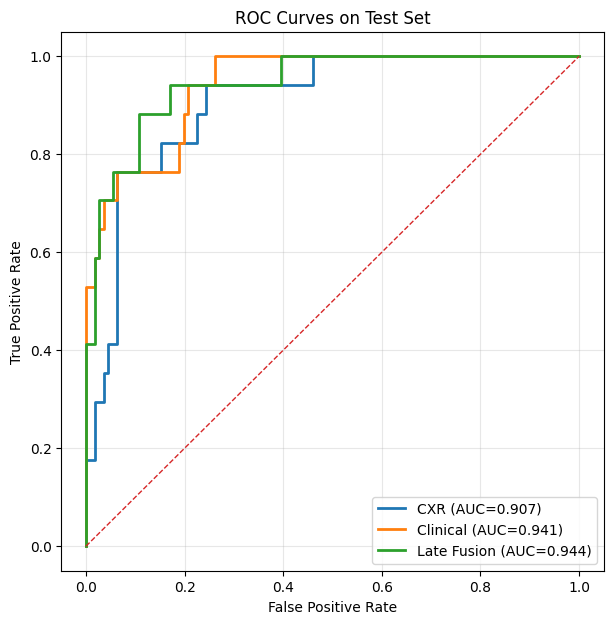

Saved: /content/drive/MyDrive/気合のCOVID19/03_TaskC_マルチモーダル/TaskC_3モデル_Test_ROC_curve.png


In [29]:
# ============================================
# Cell 29: Plot ROC curves
# ============================================

import matplotlib.pyplot as plt

plt.figure(figsize=(7, 7))

for model_name, prob in models.items():

    fpr, tpr, _ = roc_curve(
        y_test,
        prob
    )

    model_auc = roc_auc_score(
        y_test,
        prob
    )

    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f"{model_name} (AUC={model_auc:.3f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves on Test Set")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)

ROC_FIG_PATH = os.path.join(
    BASE_DIR,
    "03_TaskC_マルチモーダル",
    "TaskC_3モデル_Test_ROC_curve.png"
)

plt.savefig(
    ROC_FIG_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", ROC_FIG_PATH)

In [30]:
# ============================================
# Cell 30: PR curve data
# ============================================

from sklearn.metrics import precision_recall_curve

pr_rows = []

for model_name, prob in models.items():

    precision, recall, thresholds = precision_recall_curve(
        y_test,
        prob
    )

    # thresholdsはprecision/recallより1つ短い
    thresholds_full = list(thresholds) + [float("nan")]

    temp = pd.DataFrame({
        "model": model_name,
        "precision": precision,
        "recall": recall,
        "threshold": thresholds_full
    })

    pr_rows.append(temp)

pr_curve_data = pd.concat(
    pr_rows,
    ignore_index=True
)

PR_DATA_PATH = os.path.join(
    BASE_DIR,
    "03_TaskC_マルチモーダル",
    "TaskC_3モデル_Test_PR_curve_data.csv"
)

pr_curve_data.to_csv(
    PR_DATA_PATH,
    index=False,
    encoding="utf-8-sig"
)

print("Saved:", PR_DATA_PATH)
display(pr_curve_data.head())

Saved: /content/drive/MyDrive/気合のCOVID19/03_TaskC_マルチモーダル/TaskC_3モデル_Test_PR_curve_data.csv


,model,precision,recall,threshold
0,CXR,0.132812,1.0,0.017999
1,CXR,0.133858,1.0,0.024324
2,CXR,0.134921,1.0,0.025486
3,CXR,0.136000,1.0,0.025648
4,CXR,0.137097,1.0,0.026944


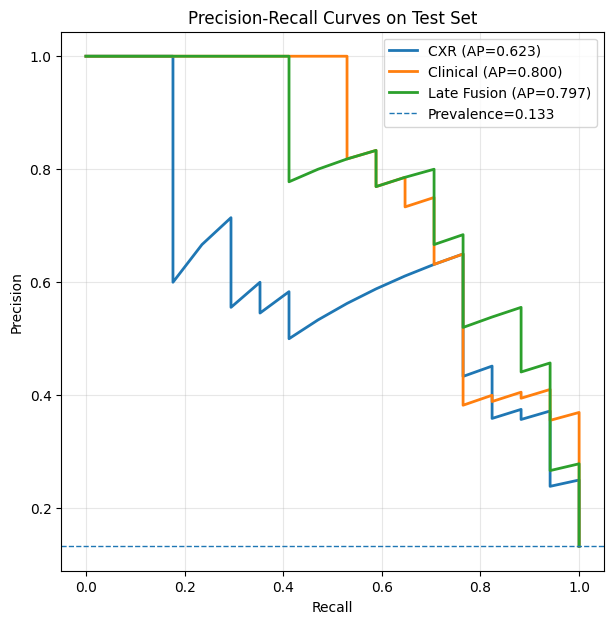

Saved: /content/drive/MyDrive/気合のCOVID19/03_TaskC_マルチモーダル/TaskC_3モデル_Test_PR_curve.png


In [31]:
# ============================================
# Cell 31: Plot PR curves
# ============================================

from sklearn.metrics import average_precision_score

plt.figure(figsize=(7, 7))

for model_name, prob in models.items():

    precision, recall, _ = precision_recall_curve(
        y_test,
        prob
    )

    ap = average_precision_score(
        y_test,
        prob
    )

    plt.plot(
        recall,
        precision,
        linewidth=2,
        label=f"{model_name} (AP={ap:.3f})"
    )

# Test陽性率
prevalence = y_test.mean()

plt.axhline(
    prevalence,
    linestyle="--",
    linewidth=1,
    label=f"Prevalence={prevalence:.3f}"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves on Test Set")
plt.legend(loc="best")
plt.grid(alpha=0.3)

PR_FIG_PATH = os.path.join(
    BASE_DIR,
    "03_TaskC_マルチモーダル",
    "TaskC_3モデル_Test_PR_curve.png"
)

plt.savefig(
    PR_FIG_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", PR_FIG_PATH)